MOBILE PHONE USGAE AMONG UNIVERSITY STUDENTS


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mobile Phone Usage Among University Students Dataframe.csv")

df.head()

,Timestamp,Gender,Age,Year of Study,Major/Intended Major,"Average mobile screen time per day? (This question has to be accurate so please check this from your settings 🙏 🙏. in Hour:Min, don't worry about AM/PM)",What time of the day do you use your phone the most?⏰,What day of the week do you use your phone the most?📅,Most used app(Genre of app),Do you use your phone for academic purposes?,Number of people in your friend circle 👥👥,How would you rate your anxiety level on a scale of 1-5(with 5 being most anxious)😬,Do you play any sport? ⚽ 🏀 🏏,What is your CGPA? 🎓,Would you be willing to reduce your phone usage if it meant improving your academic performance?,"Do you use strategies to manage your phone usage? (e.g, Setting usage limits, Using apps to track usage, Turning off notifications, Scheduled phone-free times )"
0,10/14/2024 22:30:12,Male,20,Freshman,Sciences/Engineering/Comp Sci,5:20:00 AM,Night,Monday,"Social Media(Facebook, Instagram, Snapchat etc)",Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,10/14/2024 23:22:14,Male,20,Junior,Arts 🎨 / Humanities and Social Science💲,6:37:00 AM,Evening,Sunday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,4,4,No,3.3-3.6,Yes,No
2,10/14/2024 23:24:55,Male,20,Junior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,8:08:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,10/14/2024 23:28:01,Male,18,Senior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,6:21:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,8,3,Yes,3.3-3.6,Yes,No
4,10/14/2024 23:28:18,Male,20,Junior,Business Studies 📈,6:00:00 AM,Night,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,10,3,No,2.5-3.0,Yes,Yes


In [3]:
# dropping timestamps
df = df.drop(columns=['Timestamp'])


df.head()

,Gender,Age,Year of Study,Major/Intended Major,"Average mobile screen time per day? (This question has to be accurate so please check this from your settings 🙏 🙏. in Hour:Min, don't worry about AM/PM)",What time of the day do you use your phone the most?⏰,What day of the week do you use your phone the most?📅,Most used app(Genre of app),Do you use your phone for academic purposes?,Number of people in your friend circle 👥👥,How would you rate your anxiety level on a scale of 1-5(with 5 being most anxious)😬,Do you play any sport? ⚽ 🏀 🏏,What is your CGPA? 🎓,Would you be willing to reduce your phone usage if it meant improving your academic performance?,"Do you use strategies to manage your phone usage? (e.g, Setting usage limits, Using apps to track usage, Turning off notifications, Scheduled phone-free times )"
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,5:20:00 AM,Night,Monday,"Social Media(Facebook, Instagram, Snapchat etc)",Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts 🎨 / Humanities and Social Science💲,6:37:00 AM,Evening,Sunday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,4,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,8:08:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,6:21:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,8,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies 📈,6:00:00 AM,Night,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,10,3,No,2.5-3.0,Yes,Yes


In [4]:
#redefining column names
df.columns = [
    'Gender', 
    'Age', 
    'Year_of_Study', 
    'Major', 
    'Screen_Time', 
    'Phone_Usage_Time', 
    'Phone_Usage_Day', 
    'Most_Used_App', 
    'Academic_Usage', 
    'Friend_Circle_Size', 
    'Anxiety_Level', 
    'Plays_Sport', 
    'CGPA', 
    'Willing_to_Reduce_Usage', 
    'Phone_Usage_Management'
]


df.head()

,Gender,Age,Year_of_Study,Major,Screen_Time,Phone_Usage_Time,Phone_Usage_Day,Most_Used_App,Academic_Usage,Friend_Circle_Size,Anxiety_Level,Plays_Sport,CGPA,Willing_to_Reduce_Usage,Phone_Usage_Management
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,5:20:00 AM,Night,Monday,"Social Media(Facebook, Instagram, Snapchat etc)",Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts 🎨 / Humanities and Social Science💲,6:37:00 AM,Evening,Sunday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,4,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,8:08:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,6:21:00 AM,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,8,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies 📈,6:00:00 AM,Night,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,10,3,No,2.5-3.0,Yes,Yes


In [5]:
#Data cleaning on screen time (removing AM/PM etc)
df['Screen_Time'] = df['Screen_Time'].str.replace(r'(\d{1,2}):(\d{2}):(\d{2})\s?(AM|PM)', r'\1:\2', regex=True)
df.head()

,Gender,Age,Year_of_Study,Major,Screen_Time,Phone_Usage_Time,Phone_Usage_Day,Most_Used_App,Academic_Usage,Friend_Circle_Size,Anxiety_Level,Plays_Sport,CGPA,Willing_to_Reduce_Usage,Phone_Usage_Management
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,5:20,Night,Monday,"Social Media(Facebook, Instagram, Snapchat etc)",Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts 🎨 / Humanities and Social Science💲,6:37,Evening,Sunday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,4,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,8:08,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,6:21,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,8,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies 📈,6:00,Night,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,10,3,No,2.5-3.0,Yes,Yes


In [6]:
# Screen Time cleaning (Converting to minutes)
df['Screen_Time'] = df['Screen_Time'].str.split(':').apply(lambda x: int(x[0]) * 60 + int(x[1]))
df['Screen_Time']

0      320
1      397
2      488
3      381
4      360
      ... 
197    215
198    491
199    280
200    281
201    311
Name: Screen_Time, Length: 202, dtype: int64

In [7]:
# Renaming column
df = df.rename(columns={'Screen_Time': 'screen_time_in_hrs_mins'})

In [8]:
df.head()

,Gender,Age,Year_of_Study,Major,screen_time_in_hrs_mins,Phone_Usage_Time,Phone_Usage_Day,Most_Used_App,Academic_Usage,Friend_Circle_Size,Anxiety_Level,Plays_Sport,CGPA,Willing_to_Reduce_Usage,Phone_Usage_Management
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,320,Night,Monday,"Social Media(Facebook, Instagram, Snapchat etc)",Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts 🎨 / Humanities and Social Science💲,397,Evening,Sunday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,4,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,488,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻,381,Evening,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,8,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies 📈,360,Night,Saturday,"Social Media(Facebook, Instagram, Snapchat etc) 📲",No,10,3,No,2.5-3.0,Yes,Yes


In [9]:
#Data Cleaning on Major
df["Major"] = df["Major"].replace({
    "Sciences 🧬/Engineering 🔢/Comp Sci 🧑‍💻": "Sciences/Engineering/Comp Sci",
    "Arts 🎨 / Humanities and Social Science💲": "Arts/Humanities and Social Science",
    "Medical 🩺": "Medical",
    "Business Studies 📈": "Business Studies",
    "Law ⚖️":"Law"
})

df["Major"] = df["Major"].apply(lambda x: x if x in ["Sciences/Engineering/Comp Sci", "Arts/Humanities and Social Science", "Medical", "Business Studies", "Law"] else np.nan)

In [10]:
# Data Cleaning on Most Used App
df['Most_Used_App'] = df['Most_Used_App'].str.split('(', n=1).str[0].str.split().str[0]
df['Most_Used_App'] = df['Most_Used_App'].replace('Social', 'Social Media')

In [11]:
df

,Gender,Age,Year_of_Study,Major,screen_time_in_hrs_mins,Phone_Usage_Time,Phone_Usage_Day,Most_Used_App,Academic_Usage,Friend_Circle_Size,Anxiety_Level,Plays_Sport,CGPA,Willing_to_Reduce_Usage,Phone_Usage_Management
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,320,Night,Monday,Social Media,Yes,5,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts/Humanities and Social Science,397,Evening,Sunday,Social Media,Yes,4,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences/Engineering/Comp Sci,488,Evening,Saturday,Social Media,Yes,20,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences/Engineering/Comp Sci,381,Evening,Saturday,Social Media,No,8,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies,360,Night,Saturday,Social Media,No,10,3,No,2.5-3.0,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Male,25,Senior,Medical,215,Night,Friday,Entertainment,No,20,2,Yes,2.5-3.0,Yes,No
198,Female,22,Sophomore,Law,491,Night,Sunday,Gaming,No,2,3,No,2.5-3.0,Yes,No
199,Male,20,Junior,Sciences/Engineering/Comp Sci,280,Night,Saturday,Entertainment,Yes,9,4,Yes,3.0-3.3,Yes,No
200,Female,22,Sophomore,Business Studies,281,Night,Sunday,Studying,Yes,2,5,No,3.6-4.0,Yes,Yes


In [12]:
# Data Cleaning on friend Circle. If text was given, we converted it to the data's mean. If value>50, discarded as outlier and also replaced with 0.
# had to look up isinstance and map func
def convert_to_zero(value):
    if isinstance(value, str) and not value.isdigit():
        return 0
    return value

def convert_range(value):
    if isinstance(value, str) and '-' in value:
        try:
            start, end = map(int, value.split('-'))
            return (start + end) / 2
        except ValueError:
            return 0
    return value


df['Friend_Circle_Size'] = df['Friend_Circle_Size'].apply(convert_range)
df['Friend_Circle_Size'] = df['Friend_Circle_Size'].apply(convert_to_zero)


df['Friend_Circle_Size'] = df['Friend_Circle_Size'].apply(lambda x: 0 if isinstance(x, (int, float)) and x > 50 else x)

df['Friend_Circle_Size'] = pd.to_numeric(df['Friend_Circle_Size'], errors='coerce')

df['Friend_Circle_Size'] = df['Friend_Circle_Size'].fillna(0)

mean_value = df[df['Friend_Circle_Size'] > 0]['Friend_Circle_Size'].mean()

df['Friend_Circle_Size'] = df['Friend_Circle_Size'].replace(0, mean_value)

df['Friend_Circle_Size'] = df['Friend_Circle_Size'].apply(lambda x: np.floor(x) if isinstance(x, (int, float)) else x) # for decimal

df['Friend_Circle_Size'] = df['Friend_Circle_Size'].apply(lambda x: 0 if x > 50 else x)

In [13]:
# *Data Cleaning Complete*

In [14]:
# 1) Screen Usage vs Academic Performance(Research Question 1, details of graphs in blog post)

Added more than one graph for the same attribute below in some cases(just for visualisation purposes, however only one graph is present in blog)

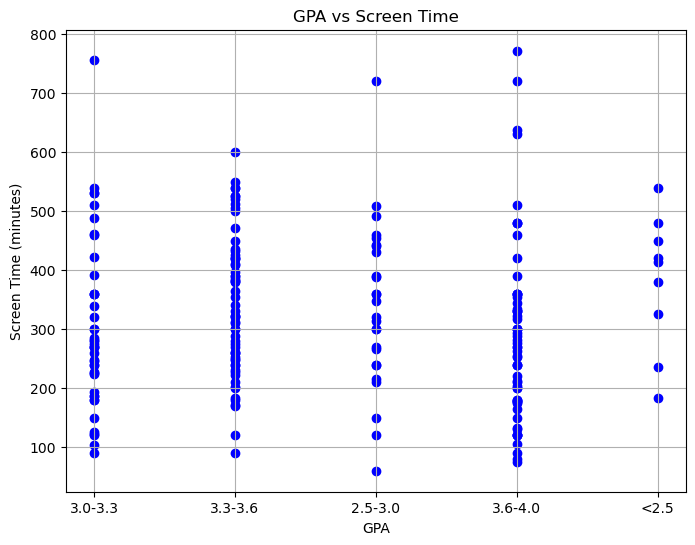

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(df['CGPA'], df['screen_time_in_hrs_mins'], color='blue')

plt.xlabel('GPA')
plt.ylabel('Screen Time (minutes)')
plt.title('GPA vs Screen Time')
plt.grid(True)

plt.show()

In [16]:
pivot_table = df.pivot_table(
    index='CGPA',  
    values='screen_time_in_hrs_mins', 
    aggfunc='mean'
)

(pivot_table)

,screen_time_in_hrs_mins
CGPA,
2.5-3.0,338.500000
3.0-3.3,300.232558
3.3-3.6,342.290323
3.6-4.0,288.274194
<2.5,380.777778


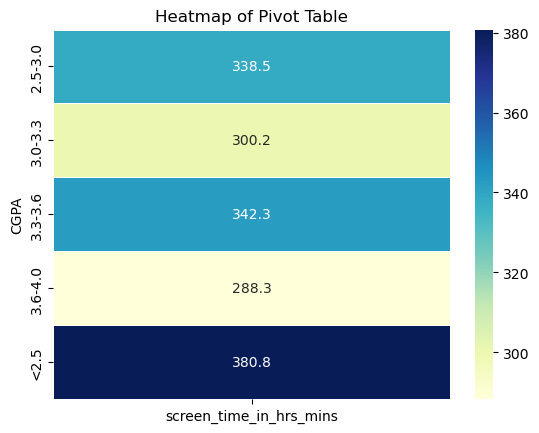

In [17]:
# just plotting for some clarification
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=0.5)
plt.title('Heatmap of Pivot Table')
plt.show()

<Figure size 800x600 with 0 Axes>

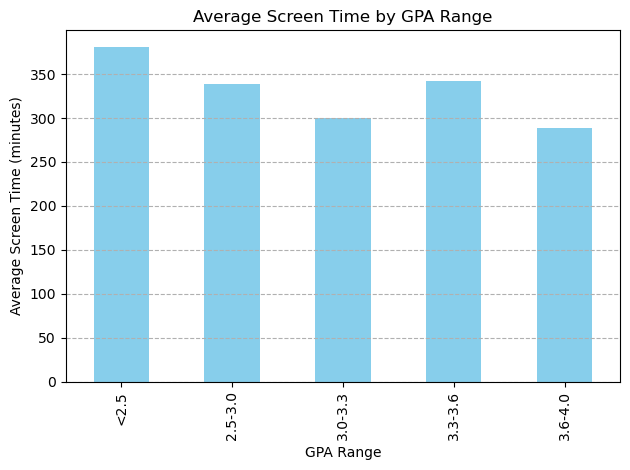

In [18]:
pivot_table = pivot_table.reindex(['<2.5', '2.5-3.0', '3.0-3.3', '3.3-3.6', '3.6-4.0'])

plt.figure(figsize=(8, 6))
pivot_table.plot(kind='bar', legend=False, color='skyblue')

plt.xlabel('GPA Range')
plt.ylabel('Average Screen Time (minutes)')
plt.title('Average Screen Time by GPA Range')
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

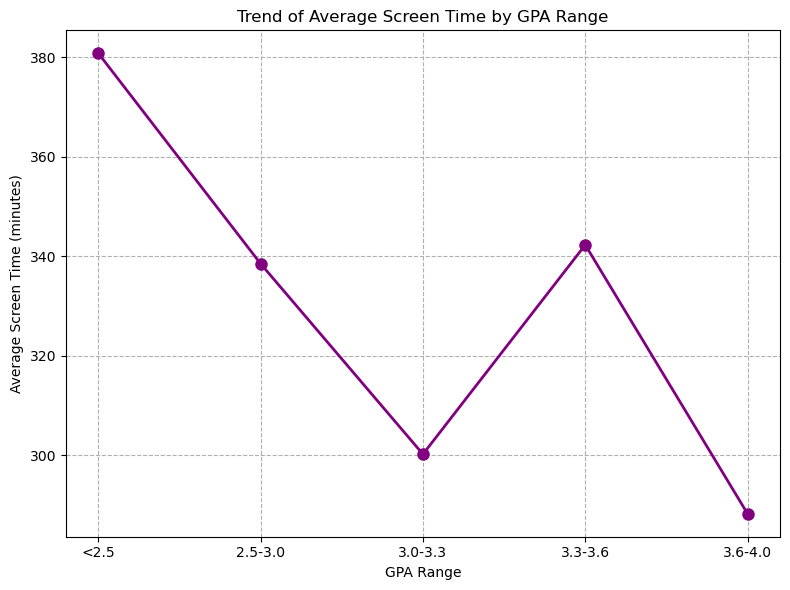

In [19]:
# just for some visualistaion

plt.figure(figsize=(8, 6))
plt.plot(
    pivot_table.index, 
    pivot_table['screen_time_in_hrs_mins'], 
    marker='o', 
    color='purple', 
    linewidth=2, 
    markersize=8
)

plt.xlabel('GPA Range')
plt.ylabel('Average Screen Time (minutes)')
plt.title('Trend of Average Screen Time by GPA Range')
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

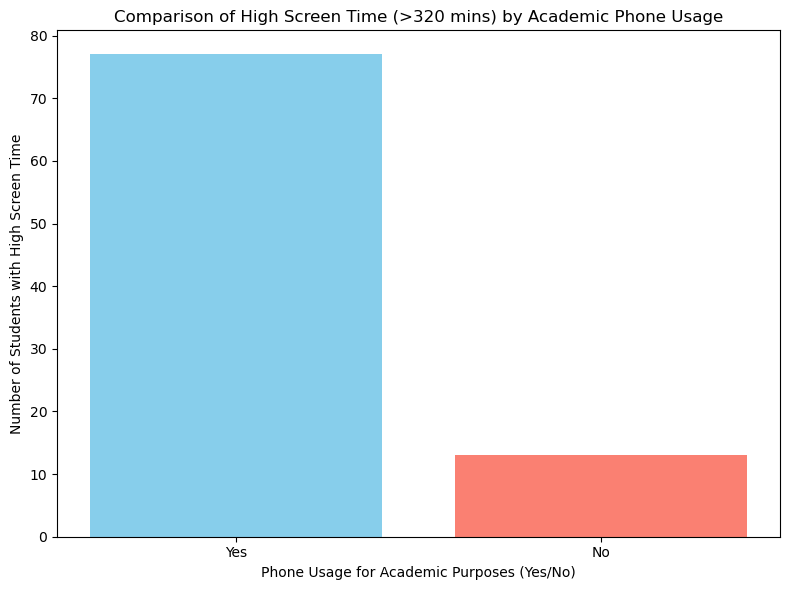

In [20]:
threshold = 320


yes_high_screen_time = df[(df['Willing_to_Reduce_Usage'] == 'Yes') & (df['screen_time_in_hrs_mins'] > threshold)].shape[0]

no_high_screen_time = df[(df['Willing_to_Reduce_Usage'] == 'No') & (df['screen_time_in_hrs_mins'] > threshold)].shape[0]

labels = ['Yes', 'No']
counts = [yes_high_screen_time, no_high_screen_time]

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['skyblue', 'salmon'])

plt.xlabel('Phone Usage for Academic Purposes (Yes/No)')
plt.ylabel('Number of Students with High Screen Time')
plt.title(f'Comparison of High Screen Time (>{threshold} mins) by Academic Phone Usage')

plt.tight_layout()
plt.show()

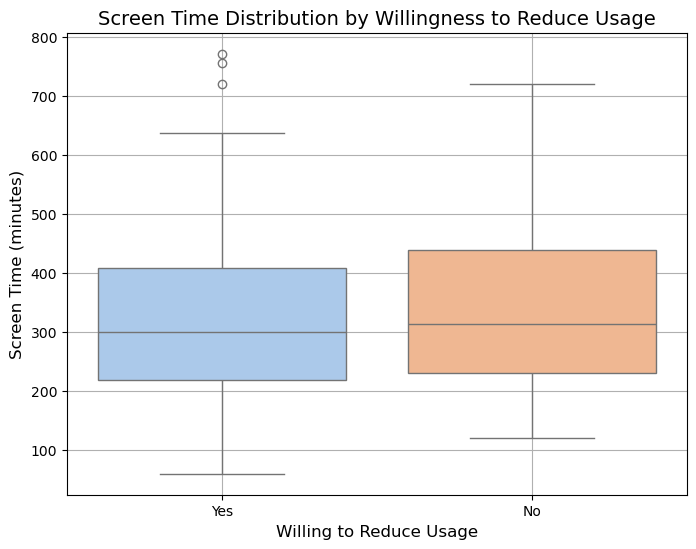

In [21]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Willing_to_Reduce_Usage', y='screen_time_in_hrs_mins', data=df, hue='Willing_to_Reduce_Usage', palette="pastel", legend=False)

plt.xlabel('Willing to Reduce Usage', fontsize=12)
plt.ylabel('Screen Time (minutes)', fontsize=12)
plt.title(f'Screen Time Distribution by Willingness to Reduce Usage', fontsize=14)

plt.grid(True)
plt.show()

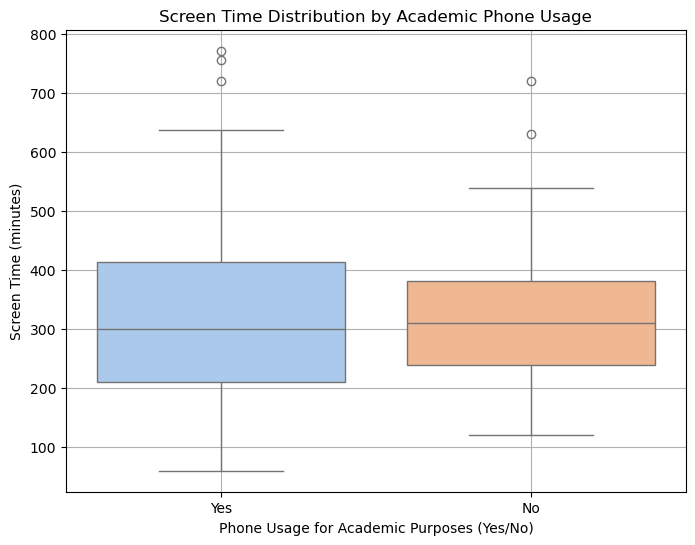

In [22]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='Academic_Usage', y='screen_time_in_hrs_mins', data=df, hue='Academic_Usage', palette="pastel", legend=False)

plt.xlabel('Phone Usage for Academic Purposes (Yes/No)')
plt.ylabel('Screen Time (minutes)')
plt.title(f'Screen Time Distribution by Academic Phone Usage')

plt.grid(True)
plt.show()

In [23]:
# 2) How does Screen Usage affect Mental Health?(Research Question 2)

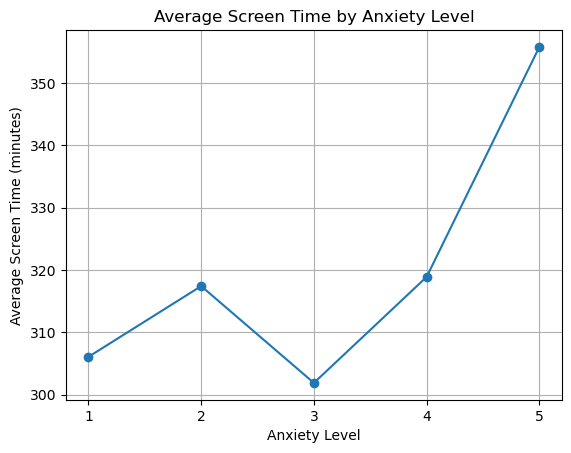

In [24]:
df['Anxiety_Level'] = df['Anxiety_Level'].astype(int)
average_screen_time = df.groupby('Anxiety_Level')['screen_time_in_hrs_mins'].mean()
average_screen_time.plot(kind='line', marker='o')
plt.title('Average Screen Time by Anxiety Level')
plt.xlabel('Anxiety Level')
plt.ylabel('Average Screen Time (minutes)')
plt.grid(True)
plt.xticks(average_screen_time.index) 
plt.show()

/var/folders/4h/76935pps3n57jry6_4wjv84r0000gn/T/ipykernel_98342/4135833454.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  app_counts.plot(kind='bar', color=plt.cm.get_cmap('Set2', len(app_counts))(range(len(app_counts))), edgecolor='black')


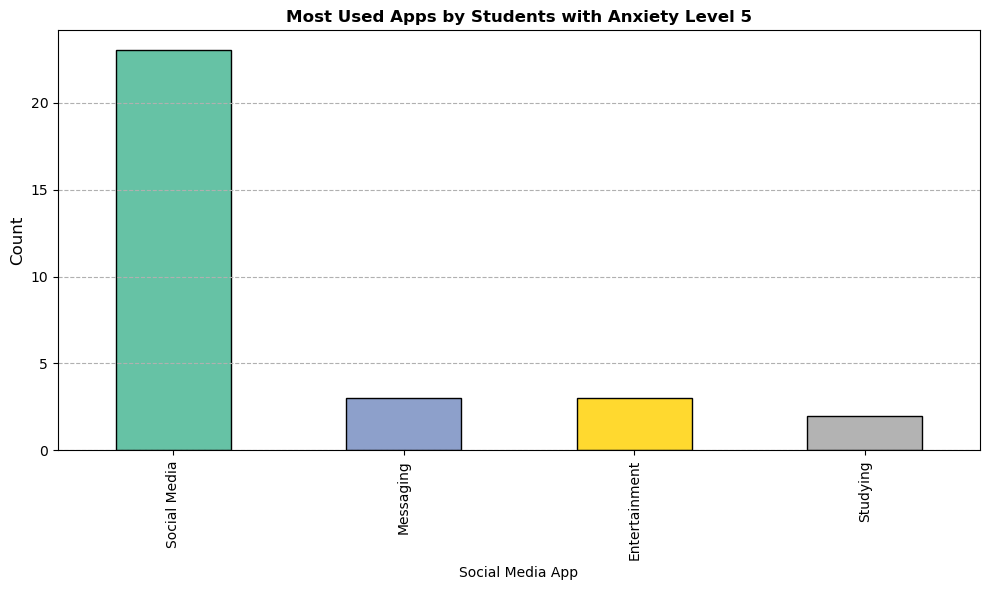

In [25]:
anxiety_level_5 = df[df['Anxiety_Level'] == 5]

app_counts = anxiety_level_5['Most_Used_App'].value_counts()

plt.figure(figsize=(10, 6))
app_counts.plot(kind='bar', color=plt.cm.get_cmap('Set2', len(app_counts))(range(len(app_counts))), edgecolor='black')

plt.title('Most Used Apps by Students with Anxiety Level 5', fontweight='bold')
plt.xlabel('Social Media App')
plt.ylabel('Count', fontsize=12)

plt.grid(axis='y', linestyle='--')

plt.tight_layout()

plt.show()

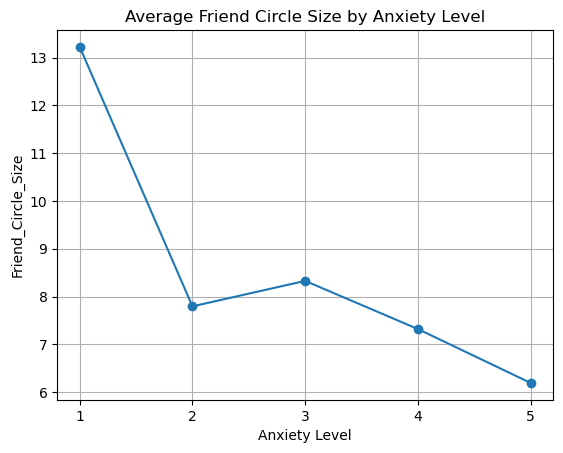

In [26]:
df['Anxiety_Level'] = df['Anxiety_Level'].astype(int)
average_screen_time = df.groupby('Anxiety_Level')['Friend_Circle_Size'].mean()
average_screen_time.plot(kind='line', marker='o')
plt.title('Average Friend Circle Size by Anxiety Level')
plt.xlabel('Anxiety Level')
plt.ylabel('Friend_Circle_Size')
plt.grid(True)
plt.xticks(average_screen_time.index) 
plt.show()

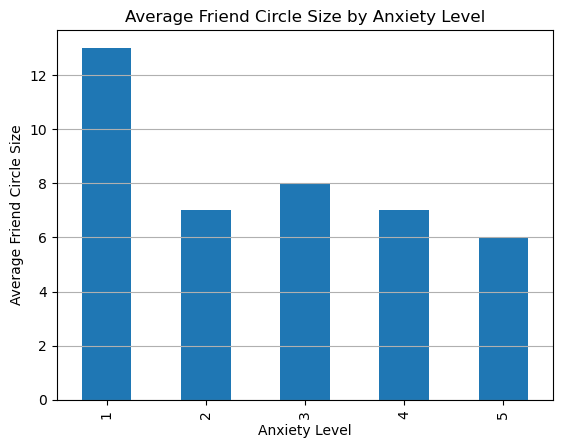

In [27]:
df['Anxiety_Level'] = pd.to_numeric(df['Anxiety_Level'], errors='coerce') 
df['Friend_Circle_Size'] = pd.to_numeric(df['Friend_Circle_Size'], errors='coerce') 

average_friend_circle_size = df.groupby('Anxiety_Level')['Friend_Circle_Size'].mean().astype(int)

average_friend_circle_size.plot(kind='bar')

plt.title('Average Friend Circle Size by Anxiety Level')
plt.xlabel('Anxiety Level')
plt.ylabel('Average Friend Circle Size')
plt.grid(True, axis='y')
plt.show()


In [28]:
#3 How do demographic and behavioral factors influence students screen usage habits? (Research Question 3)

/var/folders/4h/76935pps3n57jry6_4wjv84r0000gn/T/ipykernel_98342/3173661431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_screen_time, x='Gender', y='screen_time_in_hrs_mins', palette=['#1f77b4', '#ff7f0e'])


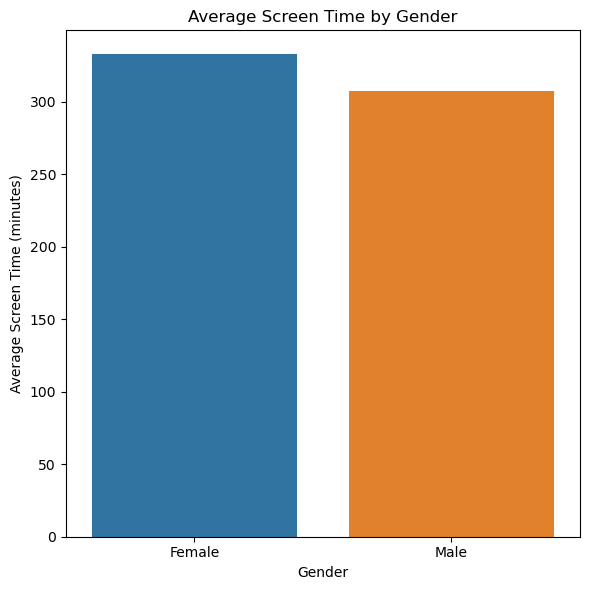

In [29]:
average_screen_time = df.groupby('Gender')['screen_time_in_hrs_mins'].mean().reset_index()

plt.figure(figsize=(6, 6))

sns.barplot(data=average_screen_time, x='Gender', y='screen_time_in_hrs_mins', palette=['#1f77b4', '#ff7f0e'])

plt.title('Average Screen Time by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Screen Time (minutes)')

plt.tight_layout()
plt.show()


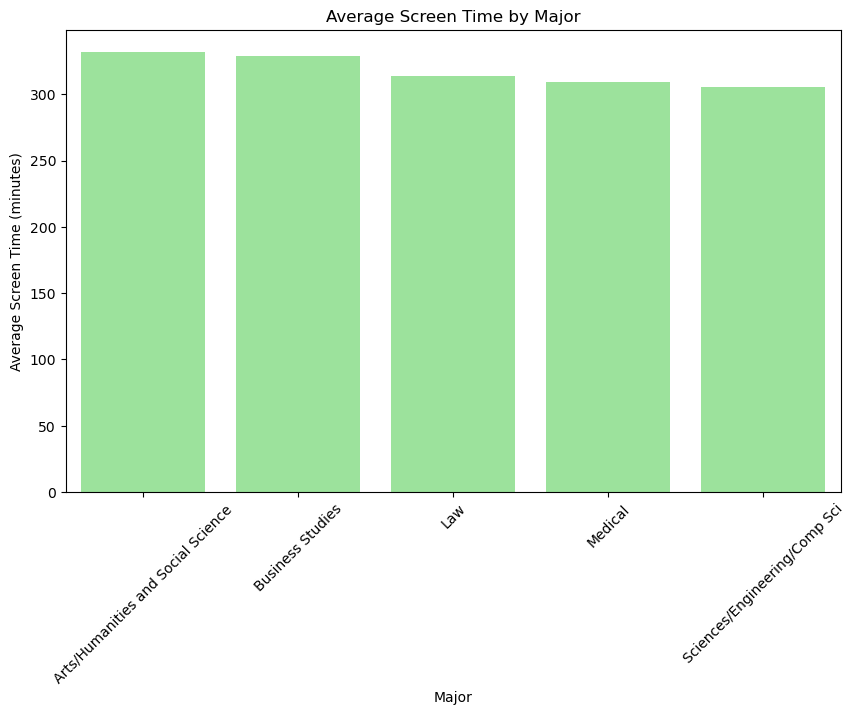

In [30]:
average_screen_time_by_major = df.groupby('Major')['screen_time_in_hrs_mins'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=average_screen_time_by_major, x='Major', y='screen_time_in_hrs_mins', color='lightgreen')
plt.title('Average Screen Time by Major')
plt.xlabel('Major')
plt.ylabel('Average Screen Time (minutes)')
plt.xticks(rotation=45)
plt.show()

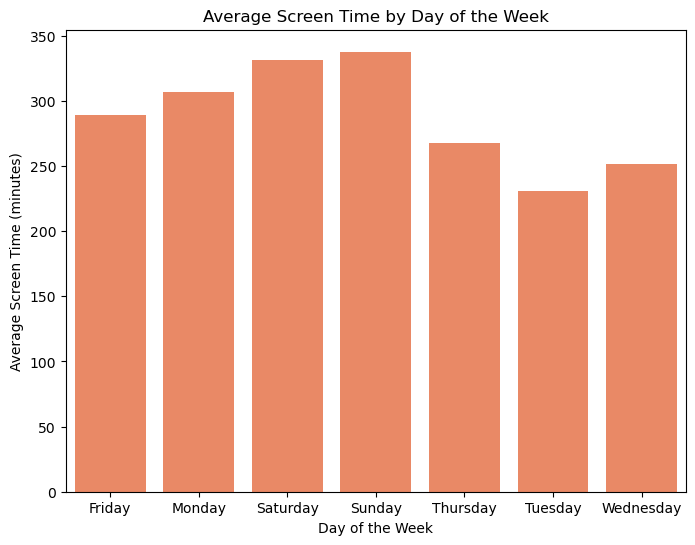

In [31]:
average_screen_time_by_day = df.groupby('Phone_Usage_Day')['screen_time_in_hrs_mins'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=average_screen_time_by_day, x='Phone_Usage_Day', y='screen_time_in_hrs_mins', color='coral')
plt.title('Average Screen Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Screen Time (minutes)')
plt.show()

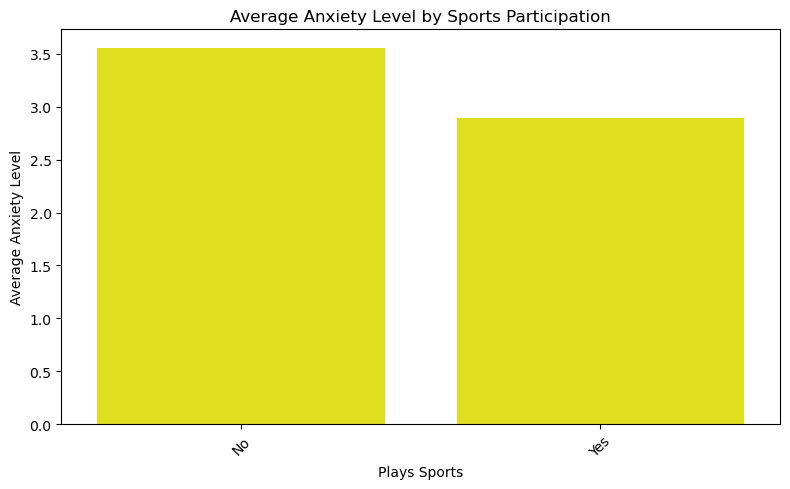

In [32]:
df['Anxiety_Level'] = df['Anxiety_Level'].astype(int)

average_anxiety = df.groupby('Plays_Sport')['Anxiety_Level'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=average_anxiety, x='Plays_Sport', y='Anxiety_Level', color = 'yellow')
plt.title('Average Anxiety Level by Sports Participation')
plt.xlabel('Plays Sports')
plt.ylabel('Average Anxiety Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

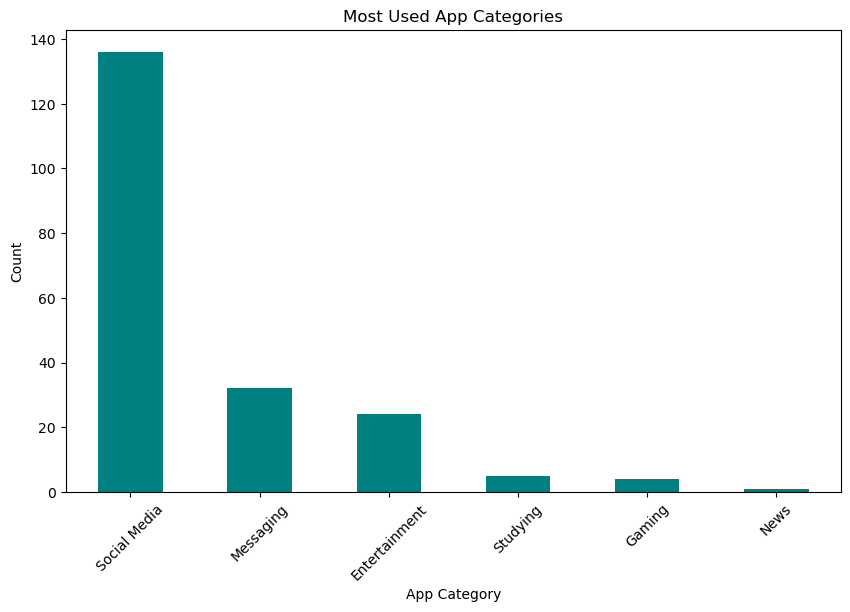

In [33]:
plt.figure(figsize=(10, 6))
df['Most_Used_App'].value_counts().plot(kind='bar', color='teal')
plt.title('Most Used App Categories')
plt.xlabel('App Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

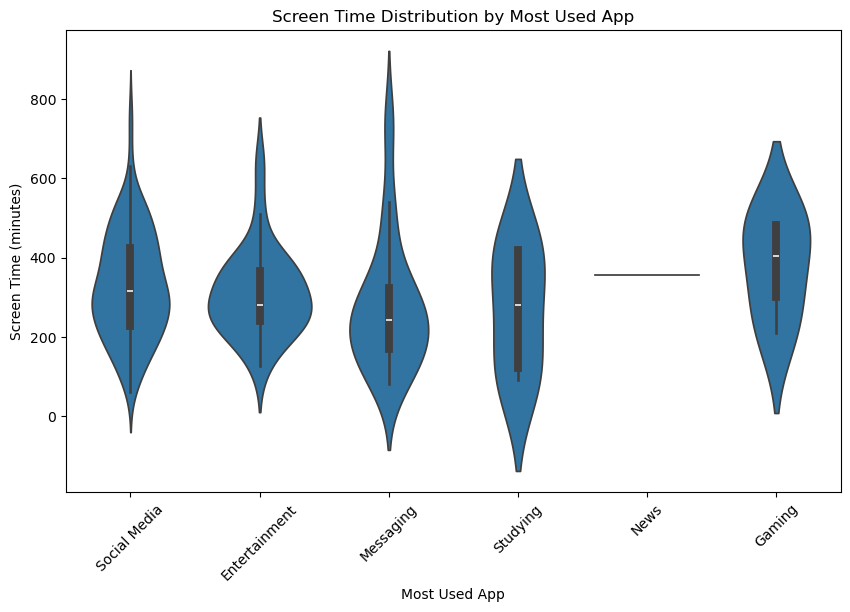

In [34]:
average_screen_time_by_app = df.groupby('Most_Used_App')['screen_time_in_hrs_mins'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Most_Used_App', y='screen_time_in_hrs_mins')
plt.title('Screen Time Distribution by Most Used App')
plt.xlabel('Most Used App')
plt.ylabel('Screen Time (minutes)')
plt.xticks(rotation=45)
plt.show()

Machine Learning Model

In [35]:
df

,Gender,Age,Year_of_Study,Major,screen_time_in_hrs_mins,Phone_Usage_Time,Phone_Usage_Day,Most_Used_App,Academic_Usage,Friend_Circle_Size,Anxiety_Level,Plays_Sport,CGPA,Willing_to_Reduce_Usage,Phone_Usage_Management
0,Male,20,Freshman,Sciences/Engineering/Comp Sci,320,Night,Monday,Social Media,Yes,5.0,5,Yes,3.0-3.3,Yes,Yes
1,Male,20,Junior,Arts/Humanities and Social Science,397,Evening,Sunday,Social Media,Yes,4.0,4,No,3.3-3.6,Yes,No
2,Male,20,Junior,Sciences/Engineering/Comp Sci,488,Evening,Saturday,Social Media,Yes,20.0,5,Yes,3.0-3.3,Yes,Yes
3,Male,18,Senior,Sciences/Engineering/Comp Sci,381,Evening,Saturday,Social Media,No,8.0,3,Yes,3.3-3.6,Yes,No
4,Male,20,Junior,Business Studies,360,Night,Saturday,Social Media,No,10.0,3,No,2.5-3.0,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,Male,25,Senior,Medical,215,Night,Friday,Entertainment,No,20.0,2,Yes,2.5-3.0,Yes,No
198,Female,22,Sophomore,Law,491,Night,Sunday,Gaming,No,2.0,3,No,2.5-3.0,Yes,No
199,Male,20,Junior,Sciences/Engineering/Comp Sci,280,Night,Saturday,Entertainment,Yes,9.0,4,Yes,3.0-3.3,Yes,No
200,Female,22,Sophomore,Business Studies,281,Night,Sunday,Studying,Yes,2.0,5,No,3.6-4.0,Yes,Yes


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from scipy import stats
import statsmodels.api as sm
from scipy.stats import pearsonr

In [37]:
# converting to categorical columns

def map_friend_circle_size(size):
    if size <= 4:
        return 1  # Small group
    elif 5 <= size <= 15:
        return 2  # Medium group
    else:
        return 3  # Large group


anxiety_map = {
    '1' : 0,
    '2': 1,
    '3': 2,
    '4': 3,
    '5': 4
}


gpa_map = {
    '<2.5' : 0,
    '2.5-3.0': 1,
    '3.0-3.3': 2,
    '3.3-3.6': 3,
    '3.6-4.0': 4
}

cgpa_mapping = {
    '2.5-3.0': 2.75,
    '3.0-3.3': 3.15,
    '3.3-3.6': 3.45,
    '3.6-4.0': 3.8
}

df['CGPA_Numeric'] = df['CGPA'].map(cgpa_mapping)
df['Anxiety_class'] = df['Anxiety_Level'].astype(str).map(anxiety_map)
df['CGPA_class'] = df['CGPA'].map(gpa_map)
df['Most_Used_App_Social_Media'] = df['Most_Used_App'].apply(lambda x: 1 if x == 'Social Media' else 0)
df['Academic_Usage_Binary'] = df['Academic_Usage'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Willing_to_Reduce_Usage_Binary'] = df['Willing_to_Reduce_Usage'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Phone_Usage_Management_Binary'] = df['Phone_Usage_Management'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Friend_circle_class'] = df['Friend_Circle_Size'].apply(map_friend_circle_size)
df['Plays_Sport_binary'] = df['Plays_Sport'].apply(lambda x: 1 if x == 'Yes' else 0)


Model for screentime, academic usage, phone management, willingness to reduce usage and cgpa

In [38]:
X = df[['screen_time_in_hrs_mins', 'Academic_Usage_Binary', 'Phone_Usage_Management_Binary', 'Willing_to_Reduce_Usage_Binary']]
y = df['CGPA_class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ovr_classifier = OneVsRestClassifier(LogisticRegression())

ovr_classifier.fit(X_train, y_train)

y_pred = ovr_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.4f}')

Accuracy: 34.1463


Model for screetime and CGPA

In [39]:
X = df['screen_time_in_hrs_mins']
y = df['CGPA_class'] 

X = X.values.reshape(-1, 1)
y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ovr_classifier = OneVsRestClassifier(LogisticRegression())

ovr_classifier.fit(X_train, y_train)

y_pred = ovr_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.4f}')

Accuracy: 39.0244


Same model as above but using SVM

In [40]:
svm_classifier = SVC(kernel='linear', random_state=42)

# Train the model
svm_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = svm_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.4f}')

Accuracy: 46.3415


Bootstrap Mean Correlation: -0.09209752203286396
95% Confidence Interval for Correlation: (-0.21827772663745593, 0.047595546904523243)


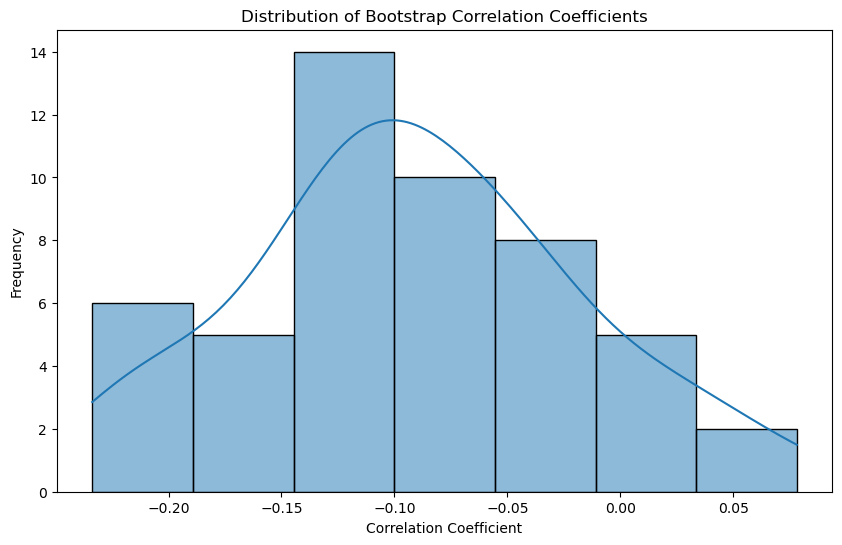

In [41]:
n_bootstrap_samples = 50
sample_size = len(df)

def bootstrap_sample(df, sample_size):
    return df.sample(n=sample_size, replace=True)

bootstrap_correlations = []
bootstrap_regression_coeffs = []

for _ in range(n_bootstrap_samples):
    bootstrap_df = bootstrap_sample(df, sample_size)
    
    correlation = bootstrap_df[['screen_time_in_hrs_mins', 'CGPA_Numeric']].corr().iloc[0, 1]
    bootstrap_correlations.append(correlation)
    
    X = bootstrap_df['screen_time_in_hrs_mins'] 
    y = bootstrap_df['CGPA_Numeric']  
    
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    bootstrap_regression_coeffs.append(model.params['screen_time_in_hrs_mins'])


mean_correlation = np.mean(bootstrap_correlations)
lower_ci_corr = np.percentile(bootstrap_correlations, 2.5)
upper_ci_corr = np.percentile(bootstrap_correlations, 97.5)

mean_coeff = np.mean(bootstrap_regression_coeffs)
lower_ci_coeff = np.percentile(bootstrap_regression_coeffs, 2.5)
upper_ci_coeff = np.percentile(bootstrap_regression_coeffs, 97.5)

print(f"Bootstrap Mean Correlation: {mean_correlation}")
print(f"95% Confidence Interval for Correlation: ({lower_ci_corr}, {upper_ci_corr})")

plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_correlations, kde=True)
plt.title('Distribution of Bootstrap Correlation Coefficients')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.show()

Bootstrap Mean Correlation: 0.07979729176757729
95% Confidence Interval for Correlation: (-0.05811465232652814, 0.20385676831352909)
Bootstrap Mean Regression Coefficient for Screen Time: 0.000677806679819033
95% Confidence Interval for Regression Coefficient: (-0.0005397299099780227, 0.001783759556975214)


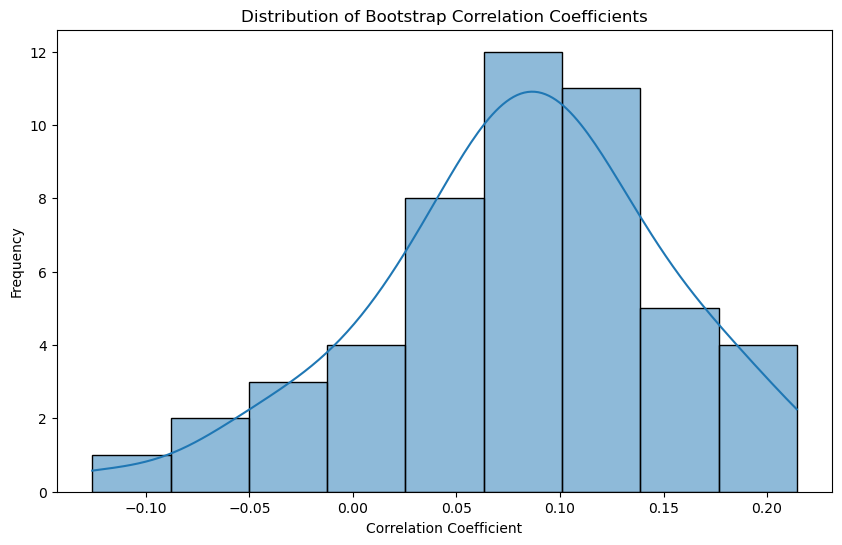

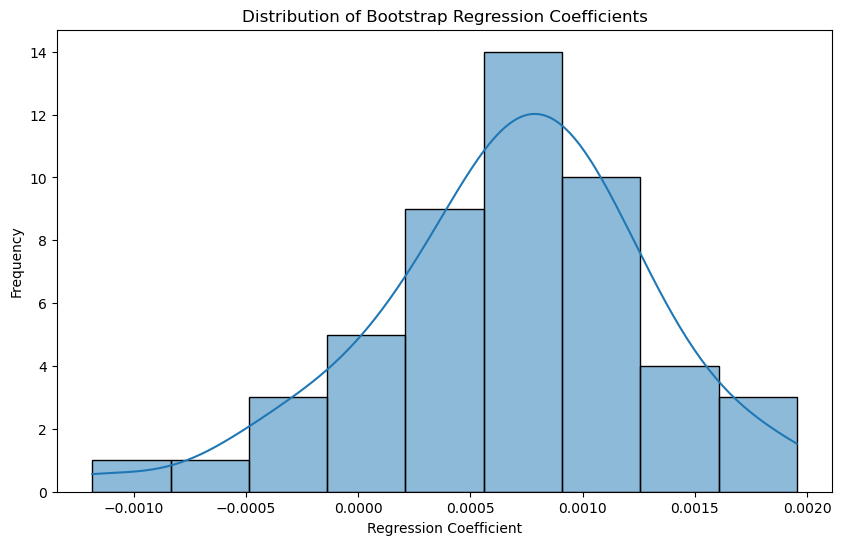

In [42]:
n_bootstrap_samples = 50
sample_size = len(df)

def bootstrap_sample(df, sample_size):
    return df.sample(n=sample_size, replace=True)

bootstrap_correlations = []
bootstrap_regression_coeffs = []

for _ in range(n_bootstrap_samples):
    bootstrap_df = bootstrap_sample(df, sample_size)
    
    correlation = bootstrap_df[['screen_time_in_hrs_mins', 'Anxiety_Level']].corr().iloc[0, 1]
    bootstrap_correlations.append(correlation)
    
    X = bootstrap_df['screen_time_in_hrs_mins']  
    y = bootstrap_df['Anxiety_Level']
    
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    
    bootstrap_regression_coeffs.append(model.params['screen_time_in_hrs_mins'])


mean_correlation = np.mean(bootstrap_correlations)
lower_ci_corr = np.percentile(bootstrap_correlations, 2.5)
upper_ci_corr = np.percentile(bootstrap_correlations, 97.5)

mean_coeff = np.mean(bootstrap_regression_coeffs)
lower_ci_coeff = np.percentile(bootstrap_regression_coeffs, 2.5)
upper_ci_coeff = np.percentile(bootstrap_regression_coeffs, 97.5)

# Print results
print(f"Bootstrap Mean Correlation: {mean_correlation}")
print(f"95% Confidence Interval for Correlation: ({lower_ci_corr}, {upper_ci_corr})")

print(f"Bootstrap Mean Regression Coefficient for Screen Time: {mean_coeff}")
print(f"95% Confidence Interval for Regression Coefficient: ({lower_ci_coeff}, {upper_ci_coeff})")

# Visualization: Distribution of bootstrap correlation coefficients
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_correlations, kde=True)
plt.title('Distribution of Bootstrap Correlation Coefficients')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.show()

# Visualization: Distribution of bootstrap regression coefficients
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_regression_coeffs, kde=True)
plt.title('Distribution of Bootstrap Regression Coefficients')
plt.xlabel('Regression Coefficient')
plt.ylabel('Frequency')
plt.show()

Statistical Inference

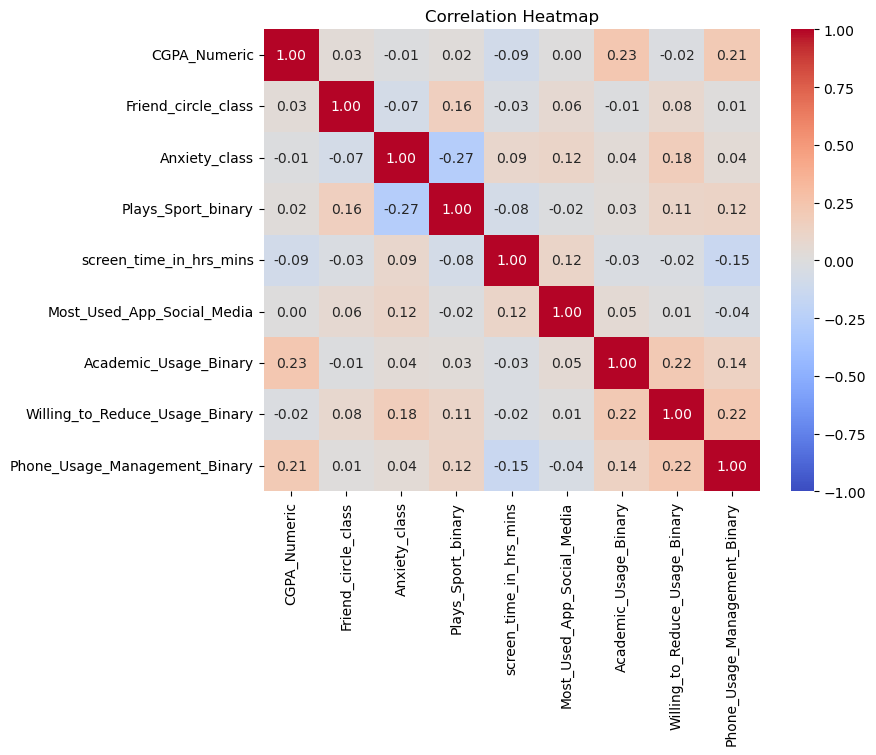

In [43]:
numerical_df = df[['CGPA_Numeric', 'Friend_circle_class', 'Anxiety_class', 'Plays_Sport_binary', 'screen_time_in_hrs_mins', 'Most_Used_App_Social_Media', 'Academic_Usage_Binary', 'Willing_to_Reduce_Usage_Binary', 'Phone_Usage_Management_Binary']]

corr_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


Note: Below we have calculated statistical inference of many variables that may also not be necessary; We included the necessary ones in the blog post.

screen time vs cgpa

Null Hypothesis (H0): There is no significant relationship between average screen time and CGPA.

Alternate Hypothesis (H1): There is a significant relationship between average screen time and CGPA.

Further details in blog post

In [44]:
df['screen_time_in_hrs_mins'].fillna(df['screen_time_in_hrs_mins'].mean(), inplace=True)
df['CGPA_Numeric'].fillna(df['CGPA_Numeric'].mean(), inplace=True)

corr, p_value = pearsonr(df['screen_time_in_hrs_mins'], df['CGPA_Numeric'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: -0.0853870953899438
P-value: 0.22694905906202073


/var/folders/4h/76935pps3n57jry6_4wjv84r0000gn/T/ipykernel_98342/2743797836.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['screen_time_in_hrs_mins'].fillna(df['screen_time_in_hrs_mins'].mean(), inplace=True)
/var/folders/4h/76935pps3n57jry6_4wjv84r0000gn/T/ipykernel_98342/2743797836.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate ob

screen time vs anxiety level - confounders

Null Hypothesis (H0):
There is no significant relationship between screen time and anxiety levels.

Alternate Hypothesis (H1):
There is a significant relationship between screen time and anxiety levels.

Further details in blog post

In [45]:
corr, p_value = pearsonr(df['screen_time_in_hrs_mins'], df['Anxiety_Level'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.08660862383530772
P-value: 0.22034729070880854


friend circle vs anxiety level(moderate negative correlation, we reject the null)

In [46]:
corr, p_value = pearsonr(df['Friend_Circle_Size'], df['Anxiety_Level'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: -0.18152537608558084
P-value: 0.009724756459312422


play sports vs anxiety level(moderate correlation, reject the null)

In [47]:
corr, p_value = pearsonr(df['Plays_Sport_binary'], df['Anxiety_Level'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: -0.2729723230795753
P-value: 8.477025135738908e-05


Use your phone for Academic vs Cgpa

Null Hypothesis (H0): There is no significant relationship between using a phone for academic purposes and CGPA.

Alternate Hypothesis (H1): There is a significant relationship between using a phone for academic purposes and CGPA.

Further details in blog post.

In [48]:
corr, p_value = pearsonr(df['Academic_Usage_Binary'], df['CGPA_Numeric'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.22259481604052903
P-value: 0.0014521615755747714


Phone USage Management vs CGPA(positive corr, reject null)

In [49]:
corr, p_value = pearsonr(df['Phone_Usage_Management_Binary'], df['CGPA_Numeric'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.2012267946873077
P-value: 0.004083287371584255


friend circle vs play sports

Null Hypothesis (H0): There is no significant relationship between friend circle size and playing sports.

Alternate Hypothesis (H1): There is a significant relationship between friend circle size and playing sports.

Further details in blog post.

In [50]:
corr, p_value = pearsonr(df['Friend_Circle_Size'], df['Plays_Sport_binary'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.17685952647992462
P-value: 0.011804756489118868


Willing to reduce Phone Usage vs Anxiety Level(string corr, reject null)

In [51]:
corr, p_value = pearsonr(df['Willing_to_Reduce_Usage_Binary'], df['Anxiety_Level'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.17663561107775028
P-value: 0.011913753347579832


Phone Usage vs Screen Time

Null Hypothesis (H0):
There is no significant relationship between phone usage management and screen time.

Alternate Hypothesis (H1):
There is a significant relationship between phone usage management and screen time.

Further details in blog post.

In [52]:
corr, p_value = pearsonr(df['Phone_Usage_Management_Binary'], df['screen_time_in_hrs_mins'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: -0.1452835263022291
P-value: 0.03911156572861849


Most Used app Social Media vs screen time(cannot reject the null, pos corr)

In [53]:
corr, p_value = pearsonr(df['Most_Used_App_Social_Media'], df['screen_time_in_hrs_mins'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.11626537718635684
P-value: 0.09939788708190826


Most Used App social media vs Anxiety Level(pos corr, cant reject the null)

In [54]:
corr, p_value = pearsonr(df['Most_Used_App_Social_Media'], df['Anxiety_Level'])

print(f"Pearson Correlation: {corr}")
print(f"P-value: {p_value}")

Pearson Correlation: 0.11715110394348402
P-value: 0.09683007704208077


Tried to include average treatment effect for our own learning(not in blog post)

ATE of Screen Time on CGPA (Supports previously found correlation, very weak negative correlation)

In [55]:
screen_time_threshold = df['screen_time_in_hrs_mins'].median()

df['High_ScreenTime'] = (df['screen_time_in_hrs_mins'] > screen_time_threshold).astype(int)

mean_cgpa_high = df[df['High_ScreenTime'] == 1]['CGPA_Numeric'].mean()
mean_cgpa_low = df[df['High_ScreenTime'] == 0]['CGPA_Numeric'].mean()

ate = mean_cgpa_high - mean_cgpa_low

print(f"Average Treatment Effect (ATE) of Screen Time on CGPA: {ate:.2f}")


Average Treatment Effect (ATE) of Screen Time on CGPA: -0.05


ATE of screen time on Anxiety (Supports previously found correlation, very weak positive correlation)

In [56]:
screen_time_threshold = df['screen_time_in_hrs_mins'].median() 

treatment_group = df[df['screen_time_in_hrs_mins'] > screen_time_threshold]['Anxiety_class']
control_group = df[df['screen_time_in_hrs_mins'] <= screen_time_threshold]['Anxiety_class']

avg_anxiety_treatment = treatment_group.mean()
avg_anxiety_control = control_group.mean()

ate_anxiety = avg_anxiety_treatment - avg_anxiety_control

print("ATE of screen time on anxiety:", ate_anxiety)


ATE of screen time on anxiety: 0.05935534591194935


Blog Post: https://medium.com/@raahem619/mobile-phone-usage-among-university-students-d896e45df7b2